# Layout and composition

A figure is rarely one panel. This notebook is the toolkit for the rest: grids
with uneven proportions, panels that span, twin and secondary axes, insets,
colorbars, and figure-level chrome — ending with a complete two-panel
publication figure built from the pieces.

One thing to know before any of it: **layout is solved before anything is
drawn.** Every label, tick and title is measured first, and the panels are given
what is left. There is no `tight_layout()` to remember, no second pass, and no
figure that only looks right after you save it once and look.

In [1]:
import math
import random

import pyplotrs as plt

plt.set_font_family("Liberation Sans")
random.seed(9)

t = [i * 0.1 for i in range(121)]
signal = [math.exp(-x / 6) * math.sin(2 * x) for x in t]
noise = [s + random.gauss(0, 0.02) for s in signal]
field = [[math.sin(0.25 * j) * math.cos(0.3 * i) for j in range(40)]
         for i in range(30)]

print("ready")

ready


## Grids, and the proportions in them

`subplots(nrows, ncols)` is the whole grid API. `width_ratios` and
`height_ratios` weight the tracks — only the proportions matter, and the gutters
keep their size, so the weights move the *panels* rather than the space between
them.

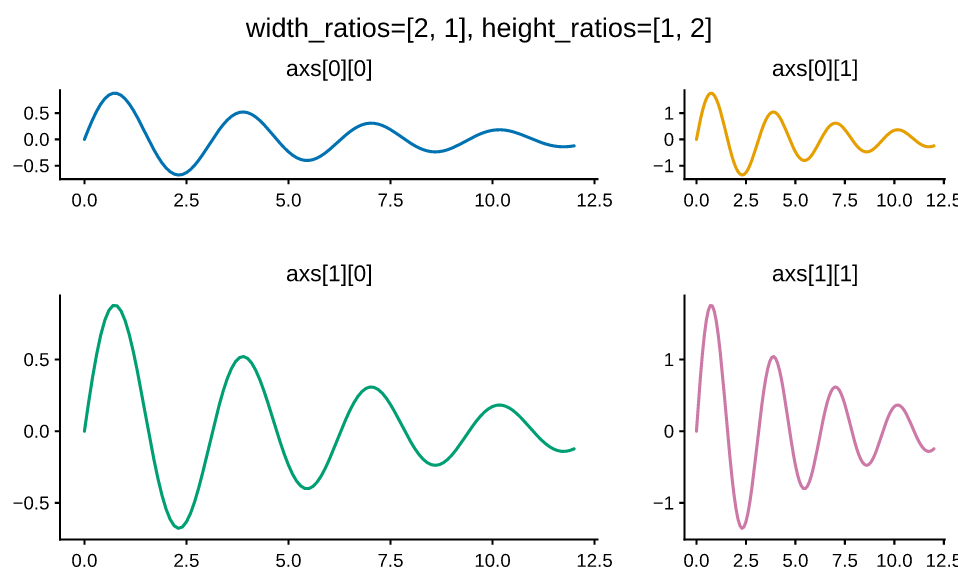

In [2]:
fig, axs = plt.subplots(2, 2, figsize=(460, 280),
                        width_ratios=[2, 1], height_ratios=[1, 2])
for row, panel_row in enumerate(axs):
    for col, ax in enumerate(panel_row):
        ax.line(t, [s * (1 + col) for s in signal], color=f"C{2 * row + col}")
        ax.set(title=f"axs[{row}][{col}]")
fig.set(suptitle="width_ratios=[2, 1], height_ratios=[1, 2]")
fig

Indexing follows the shape you asked for: a full grid gives a list of rows, so
`axs[1][0]` is row 1, column 0. A single row or column gives a flat list, and
`subplots()` with no arguments gives one bare `Axes` — the three cases you
actually unpack.

`sharex` / `sharey` compute one range across every panel that shares the axis,
which is what makes small multiples comparable. They leave the tick labels
alone; dropping the repeated ones is `set(xticklabels=[])`, a layout decision
rather than a data one.

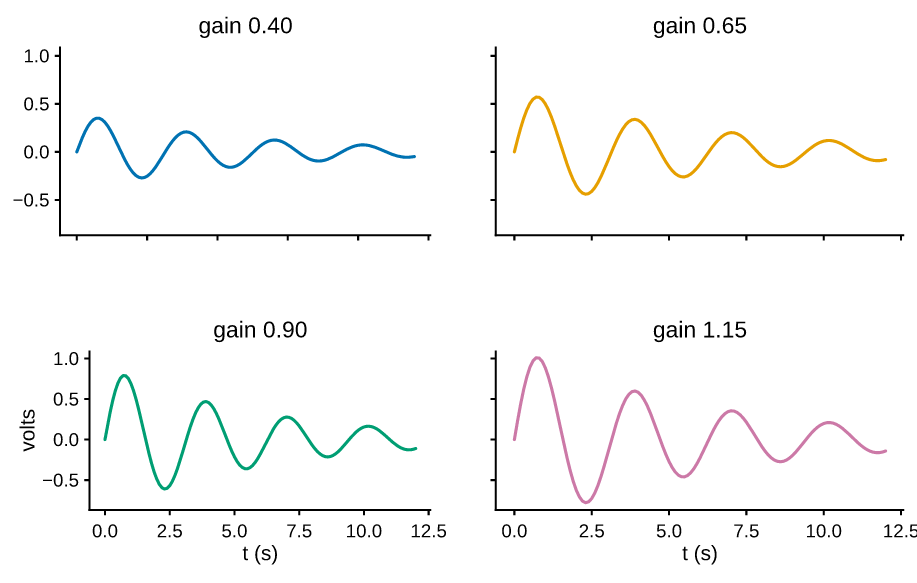

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(440, 280), sharex=True, sharey=True)
for i, ax in enumerate(a for row in axs for a in row):
    scale = 0.4 + 0.25 * i
    ax.line(t, [s * scale for s in signal], color=f"C{i}")
    ax.set(title=f"gain {scale:.2f}")

# Only the outer panels need labels once the ranges are shared.
for ax in axs[0]:
    ax.set(xticklabels=[])
for row in axs:
    row[1].set(yticklabels=[])
axs[1][0].set(xlabel="t (s)", ylabel="volts")
axs[1][1].set(xlabel="t (s)")
fig

## Panels that span: `subplot_mosaic`

Draw the layout as ASCII and get a dict of axes back. Repeated letters span,
`"."` leaves a hole, and the string is dedented for you so it means what it
looks like in your source.

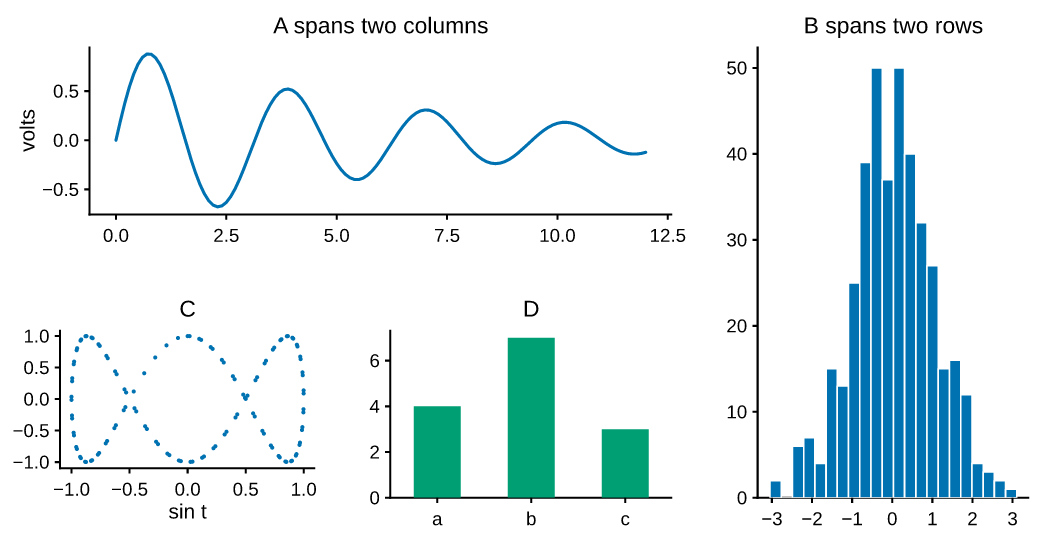

In [4]:
fig, panel = plt.subplot_mosaic(
    """
    AAB
    CDB
    """,
    figsize=(500, 260),
)

panel["A"].line(t, signal)
panel["A"].set(title="A spans two columns", ylabel="volts")

panel["B"].hist([random.gauss(0, 1) for _ in range(400)], bins=22)
panel["B"].set(title="B spans two rows")

panel["C"].scatter([math.sin(x) for x in t], [math.cos(3 * x) for x in t],
                   markersize=2)
panel["C"].set(title="C", xlabel="sin t")

panel["D"].bar(["a", "b", "c"], [4, 7, 3], color="C2")
panel["D"].set(title="D")

fig

When the layout is more naturally described by slicing than by drawing,
`add_gridspec` returns a `GridSpec` you can slice with the usual NumPy-ish
syntax — `gs[0, :]`, `gs[1:, 0]` — and hand to `add_subplot`.

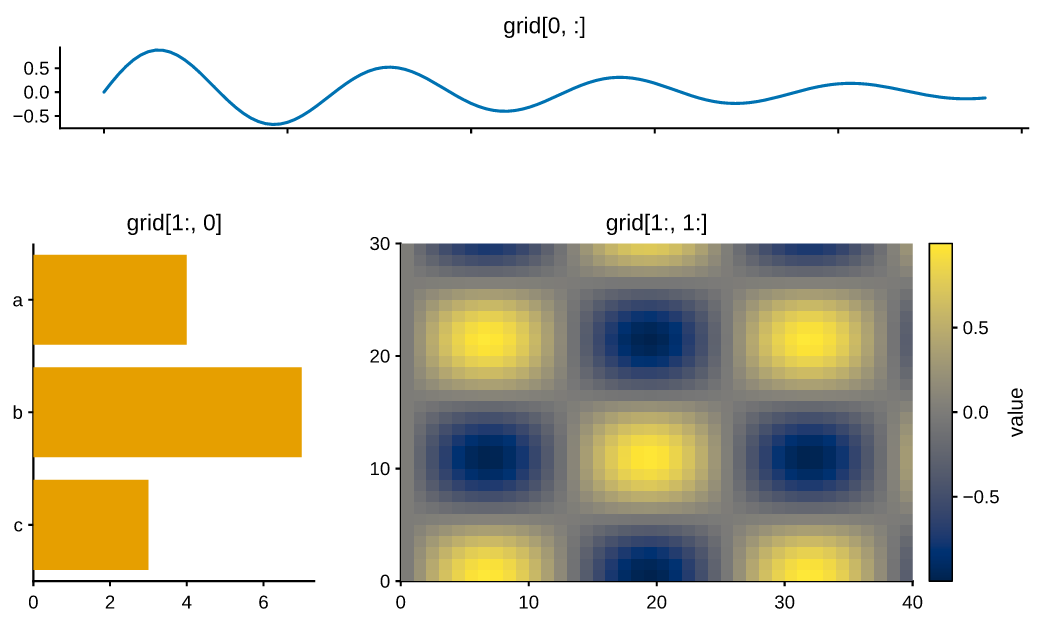

In [5]:
fig = plt.figure(figsize=(500, 300))
grid = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.4])

top = fig.add_subplot(grid[0, :])          # a full-width strip
side = fig.add_subplot(grid[1:, 0])        # two rows of the first column
main = fig.add_subplot(grid[1:, 1:])       # everything else

top.line(t, signal)
top.set(title="grid[0, :]", xticklabels=[])

side.barh(["c", "b", "a"], [3, 7, 4], color="C1")
side.set(title="grid[1:, 0]")

image = main.imshow(field, cmap="cividis", origin="lower")
fig.colorbar(image, label="value")
main.set(title="grid[1:, 1:]")

fig

## Two scales on one panel

`twinx()` returns a second axes sharing the x-axis with its own y — for a
quantity in different units over the same domain. `twiny()` is the transpose.
The twin is an ordinary `Axes`: marks, `set`, and its own color story.

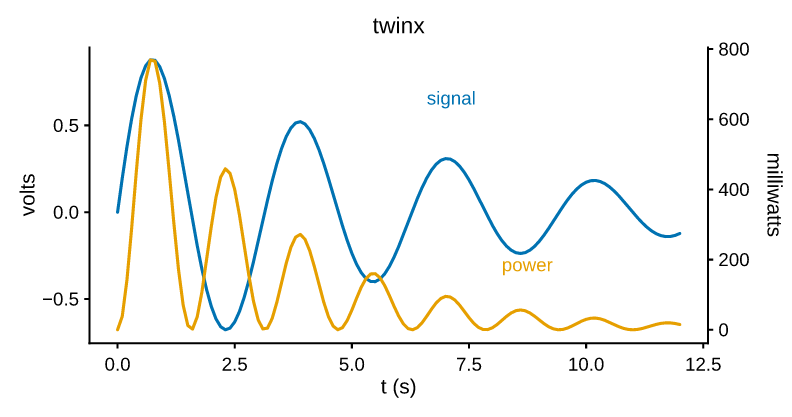

In [6]:
fig, ax = plt.subplots(figsize=(380, 200))

ax.line(t, signal, color="C0")
ax.set(title="twinx", xlabel="t (s)", ylabel="volts")

power = ax.twinx()
power.line(t, [s * s * 1000 for s in signal], color="C1")
power.set(ylabel="milliwatts")

# With two y-axes the axis label is the identifier, so each curve is named in
# its own color where it runs - both callouts placed on the primary axes, in
# its coordinates, rather than in a legend that would have to say which side.
ax.text(6.6, 0.62, "signal", color="C0", fontsize=9)
ax.text(8.2, -0.34, "power", color="C1", fontsize=9)
fig

A **secondary axis** is a different idea: not a second dataset, but a second
*labeling* of the same one, through a transform you supply as a
`(forward, inverse)` pair. Wavelength and frequency, Celsius and Fahrenheit,
samples and seconds.

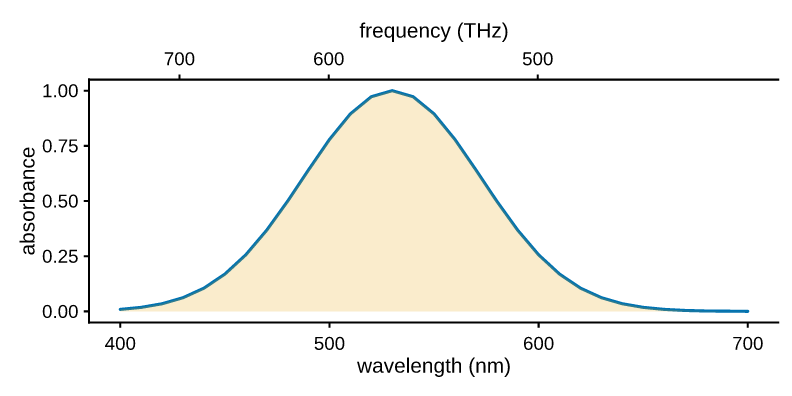

In [7]:
wavelength = [400 + 10 * i for i in range(31)]
absorbance = [math.exp(-((w - 530) / 60) ** 2) for w in wavelength]

fig, ax = plt.subplots(figsize=(380, 190))
ax.line(wavelength, absorbance)
ax.fill_between(wavelength, absorbance, alpha=0.2)
ax.set(xlabel="wavelength (nm)", ylabel="absorbance")

# c = 299792.458 nm·THz, so THz = c / nm - and the transform is its own inverse.
ax.secondary_xaxis("top", functions=(lambda nm: 299792.458 / nm,
                                     lambda thz: 299792.458 / thz),
                   label="frequency (THz)")
fig

## Insets

`inset_axes((x, y, width, height))` places a child axes in **axes-fraction
coordinates** — `(0, 0)` is the bottom left of the parent panel, `(1, 1)` the top
right. The usual job is a zoom.

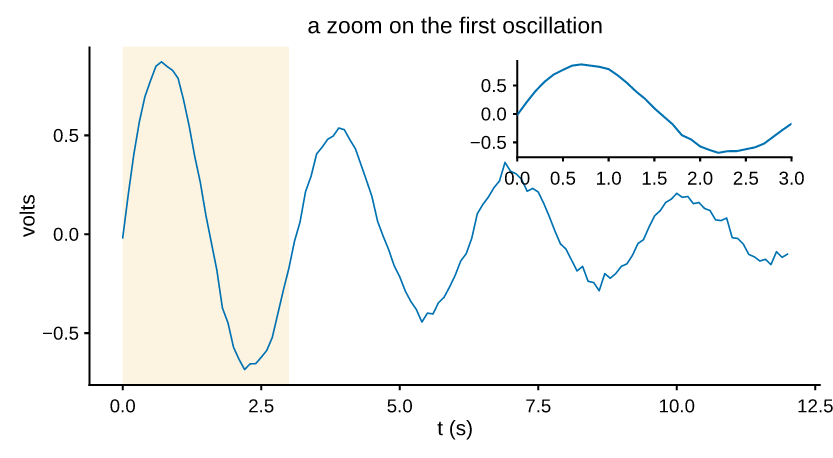

In [8]:
fig, ax = plt.subplots(figsize=(400, 220))
ax.line(t, noise, linewidth=0.8)
ax.set(title="a zoom on the first oscillation", xlabel="t (s)", ylabel="volts")

# Mark the region being magnified, then magnify it.
ax.axvspan(0.0, 3.0, alpha=0.12, color="C1")

zoom = ax.inset_axes((0.52, 0.58, 0.44, 0.38))
zoom.line(t[:31], noise[:31], linewidth=1.0)
zoom.set(xlim=(0, 3), tick_length=2)
fig

## Colorbars

`fig.colorbar(mappable)` takes the object a color-mapping mark returned and
places a bar beside that mark's panel. `orientation`, `shrink`, `ticks` and
`format` are the knobs; the label is `label=`.

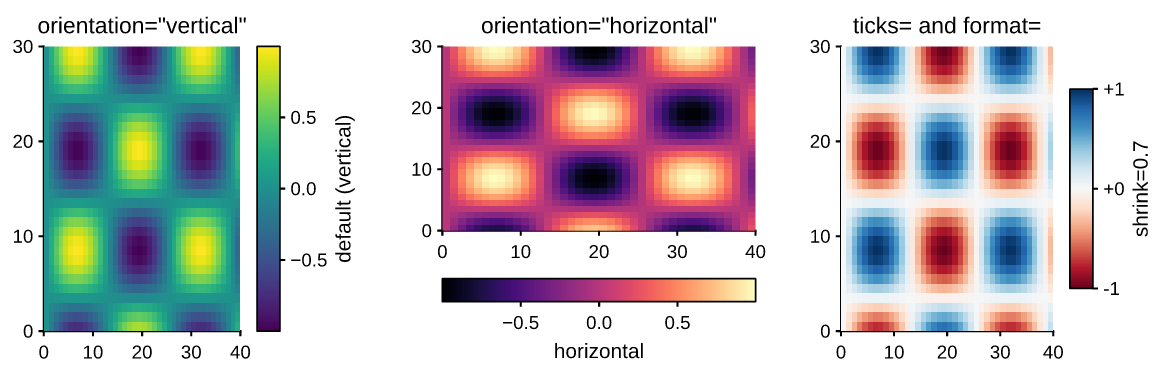

In [9]:
from pyplotrs import ticker

fig, axs = plt.subplots(1, 3, figsize=(560, 180))

a = axs[0].imshow(field, cmap="viridis")
fig.colorbar(a, label="default (vertical)")
axs[0].set(title="orientation=\"vertical\"")

b = axs[1].imshow(field, cmap="magma")
fig.colorbar(b, orientation="horizontal", label="horizontal")
axs[1].set(title="orientation=\"horizontal\"")

c = axs[2].imshow(field, cmap="RdBu")
fig.colorbar(c, shrink=0.7, ticks=[-1, 0, 1],
             format=ticker.StrMethodFormatter("{x:+.0f}"), label="shrink=0.7")
axs[2].set(title="ticks= and format=")

fig

## Figure-level chrome

`fig.set(suptitle=…)` titles the figure rather than a panel, and `fig.legend()`
draws one legend for the whole figure from every labeled mark in it — the right
call when four panels share one set of series.

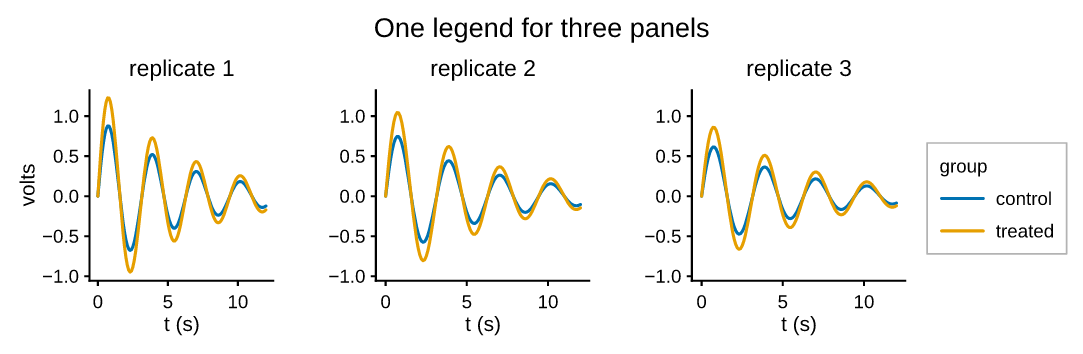

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(520, 170), sharey=True)
for i, ax in enumerate(axs):
    for series, name in enumerate(["control", "treated"]):
        ax.line(t, [s * (1 + 0.4 * series) * (1 - 0.15 * i) for s in signal],
                color=f"C{series}", label=name if i == 0 else None)
    # Pin the ticks: three short panels have no room for the six the locator
    # would fit into one wide one.
    ax.set(title=f"replicate {i + 1}", xlabel="t (s)", xticks=[0, 5, 10])
axs[0].set(ylabel="volts")

fig.legend(loc="right", title="group")
fig.set(suptitle="One legend for three panels")
fig

## Sizing a figure for where it is going

`figsize` is in **points** by default, and `units=` takes `"pt"`, `"in"`, `"cm"`
or `"mm"`. Because the canvas is the final printed size, the type on it is the
final printed type: a 9 pt tick label is 9 pt on the page, not 9 pt times
whatever scale factor the journal applies later.

Nature, one column     89×60 mm  =  252.3×170.1 pt
Nature, two columns    183×70 mm  =  518.7×198.4 pt
US Letter slide        6.5×3.0 in  =  468.0×216.0 pt


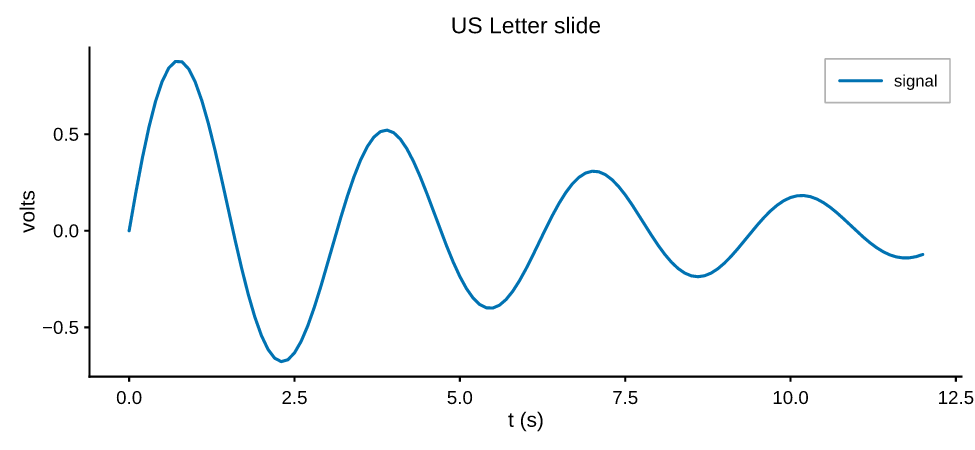

In [11]:
# Three real column widths, at the sizes they will be printed.
targets = [("Nature, one column", (89, 60), "mm"),
           ("Nature, two columns", (183, 70), "mm"),
           ("US Letter slide", (6.5, 3.0), "in")]

for name, size, units in targets:
    fig, ax = plt.subplots(figsize=size, units=units)
    ax.line(t, signal, label="signal")
    ax.set(title=name, xlabel="t (s)", ylabel="volts")
    ax.legend(fontsize=8)
    width_pt, height_pt = fig.size_pt
    print(f"{name:<22} {size[0]}×{size[1]} {units:<3} = "
          f"{width_pt:6.1f}×{height_pt:5.1f} pt")

fig   # the last one

## Putting it together

The standard shape of a fitted result: a main panel and a residual strip under
it, sharing x, weighted 3:1, with the top panel's duplicate tick labels dropped
and one title over both.

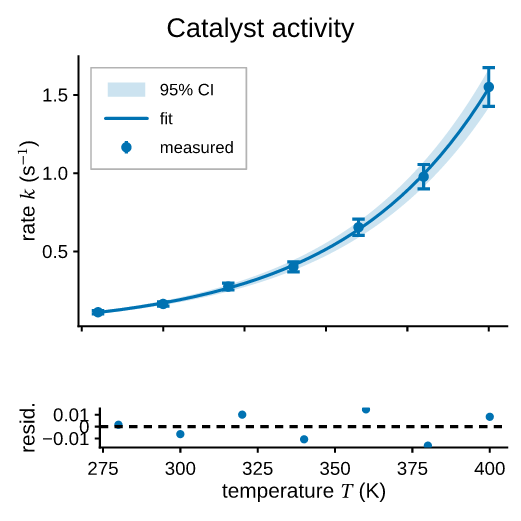

In [12]:
# Measurements, a model, and what is left over.
temp = [280, 300, 320, 340, 360, 380, 400]
rate = [0.112, 0.165, 0.276, 0.402, 0.655, 0.978, 1.551]
rate_err = [0.010, 0.014, 0.022, 0.032, 0.052, 0.078, 0.124]


def fit(ts, ys):
    """Least squares of log y = log A + k·u, with u = (t - 280)/100."""
    us = [(v - 280) / 100.0 for v in ts]
    ls = [math.log(y) for y in ys]
    ubar, lbar = sum(us) / len(us), sum(ls) / len(ls)
    k = (sum((u - ubar) * (l - lbar) for u, l in zip(us, ls))
         / sum((u - ubar) ** 2 for u in us))
    return math.exp(lbar - k * ubar), k


A, K = fit(temp, rate)
fine = [280 + i for i in range(121)]
curve = [A * math.exp(K * (v - 280) / 100.0) for v in fine]
band = [0.08 * y for y in curve]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(250, 250), sharex=True,
                                  height_ratios=[3, 1])

top.fill_between(fine, [y - e for y, e in zip(curve, band)],
                 [y + e for y, e in zip(curve, band)],
                 color="C0", alpha=0.2, label="95% CI")
top.line(fine, curve, color="C0", label="fit")
top.errorbar(temp, rate, yerr=rate_err, linestyle="none", color="C0",
             label="measured")
top.set(ylabel=r"rate $k$ (s$^{-1}$)", xticklabels=[])
top.legend(loc="upper left", fontsize=8)

residual = [r - A * math.exp(K * (v - 280) / 100.0) for v, r in zip(temp, rate)]
bottom.axhline(0.0, linestyle="dashed")
bottom.scatter(temp, residual, color="C0", markersize=4)
bottom.set(xlabel=r"temperature $T$ (K)", ylabel="resid.",
           yticks=[-0.01, 0.0, 0.01])

fig.set(suptitle="Catalyst activity")
fig

Four things are doing the work there:

- **`height_ratios=[3, 1]`** weights the rows without touching the gutter.
- **`sharex=True`** unifies the x range so the two panels line up exactly, and
  **`xticklabels=[]`** on the top panel drops the copy nobody needs.
- **`axhline`** is a guide: it spans the panel and never affects autoscaling.
- **`yticks=[…]`** pins the residual ticks to round numbers instead of the five
  the locator would fit into a short panel. Pinned positions outside the view
  are dropped, so this stays correct if the residuals shrink.

**Next:** [styling, color and text](05_styling_color_and_text.ipynb) — themes,
colormaps, the color-science tools, and `$…$` math.